<a href="https://colab.research.google.com/github/aridhapebriani/ADW/blob/main/Tugas_Minggu_4_Kelompok_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Minggu 4 Kelompok 2

Kelompok 2:

- Ain Fitri Basri (M0501251051)

- Alma Alifia Halimatunnisa (M0501251004)

- Aridha Pebriani Kusmiran (M0501251049)

In [ ]:
!pip install openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

In [ ]:
url = "https://raw.githubusercontent.com/almaalifia/Analisis-Deret-Waktu/main/harga%20emas.xlsx"

df = pd.read_excel(url)

df.head()

,Periode,Price
0,2010-01-01,413000
1,2010-02-01,408000
2,2010-03-01,406000
3,2010-04-01,408000
4,2010-05-01,429000


Cek Missing Value

In [ ]:
#cek missing values
df.isnull().sum()

,0
Periode,0
Price,0


In [ ]:
df['Periode'] = pd.to_datetime(df['Periode'])
df = df.set_index('Periode')

df.head()

,Price
Periode,
2010-01-01,413000
2010-02-01,408000
2010-03-01,406000
2010-04-01,408000
2010-05-01,429000


# ACF dan PACF

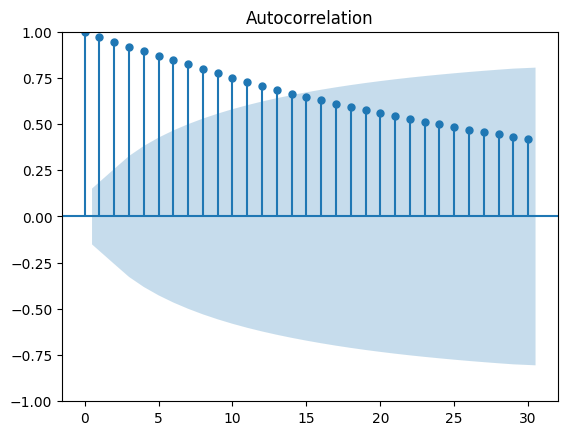

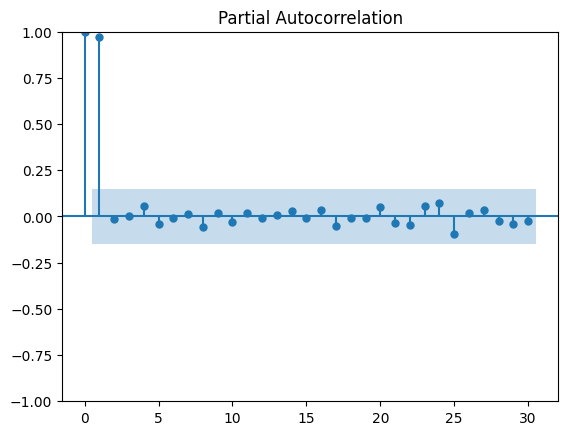

In [ ]:
plot_acf(df['Price'].dropna(), lags=30)
plt.show()

plot_pacf(df['Price'].dropna(), lags=30, method='ywm')
plt.show()

**Q1. Berdasarkan plot ACF dan PACF contoh yang diperoleh apakah deret stasioner? Mengapa?**

**Jawab:**

a. Plot ACF:

Nilai ACF pada lag1 sangat tinggi, mendekati 1. Kemudian ACF turun secara perlahan dari lag ke lag berikutnya. Hingga lag30, nilai ACF masih cukup tinggi. Selain itu, banyak spike ACF yang berada di luar batas confidence interval. Pola ini menunjukkan indikasi kuat bahwa data belum stasioner.

b. Plot PACF:

Pada plot PACF, terdapat spike yang sangat besar pada lag1 dan lag2, mendekati 1. Selain kedua lag tersebut, sebagian besar spike lag lainnya berada di dalam confidence interval dan berfluktuasi di sekitar nol.

# UJI ADF (Uji Kestasioneran)

**Uji Augmented Dicky Fuller**

H0 menyatakan deret tidak stasioner

H1 menyatakan deret stasioner

Kriteria keputusan: Tolak H0 jika p-value < 0.05

In [ ]:
# uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Price'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 0.38069722029915054
p-value: 0.9807585583017571


**Q2. Bagaimana interpreasi hasil uji tersebut? Apakah interpretasi hasil uji sama dengan interpretasi dari plot deret maupun plot ACF?**

**Jawab:**

Hasil Uji ADF yang diperoleh adalah:

- ADF Statistic: 0.3807

- p-value: 0.9808 > 0.05

Maka H0 tidak ditolak. Artinya, data harga emas belum stasioner.

Dengan demikian, deret harga emas masih mengandung unit root dan belum stasioner. Hasil uji ADF tersebut konsisten dengan hasil pemeriksaan secara visual. Pada plot deret waktu terlihat adanya kecenderungan meningkat sehingga rata-rata deret tidak konstan sepanjang waktu. Selain itu, plot ACF menunjukkan nilai autokorelasi yang tinggi dan menurun secara perlahan pada banyak lag. Oleh karena itu, baik plot deret waktu, plot ACF, maupun uji ADF memberikan kesimpulan yang sama, yaitu bahwa data harga emas belum stasioner.

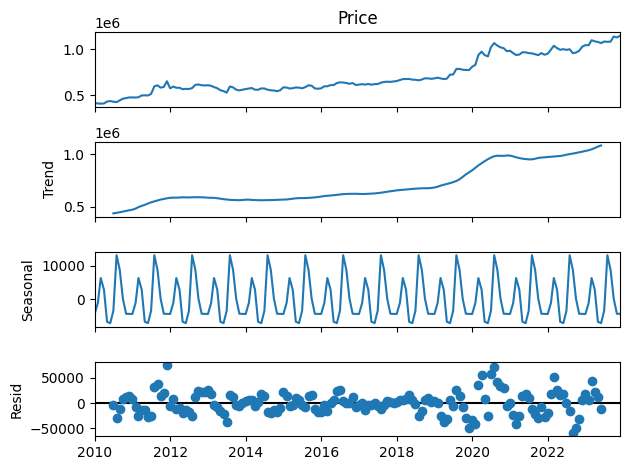

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df['Price'],
    model='additive',
    period=12
)

result.plot()
plt.show()

**Q3. Jika dilihat dari hasil dekomposisi tersebut apa interpretasi Anda? Bagaimana keterkaitan hasil dekomposisi dengan interpretasi Anda dari plot ACF dan uji ADF?**

**Jawab:**

Berdasarkan hasil dekomposisi aditif, deret harga emas menunjukkan adanya komponen tren yang cukup kuat dan cenderung meningkat dari waktu ke waktu, terutama mulai sekitar tahun 2019. Hal ini menunjukkan bahwa level atau rata-rata deret berubah sepanjang waktu. Pada komponen musiman terlihat pola yang berulang secara teratur, tetapi besar variasinya relatif kecil dibandingkan
dengan perubahan pada komponen tren. Sementara itu, komponen residual cenderung berfluktuasi di sekitar nol, meskipun masih terdapat beberapa penyimpangan yang cukup besar pada periode tertentu.

Hasil dekomposisi tersebut konsisten dengan hasil plot ACF dan uji ADF. Pada plot ACF, nilai autokorelasi pada lag awal sangat tinggi dan menurun secara perlahan pada banyak lag. Pola tersebut menunjukkan persistensi yang kuat dan merupakan indikasi bahwa deret belum stasioner. Hasil uji ADF juga memberikan p-value sebesar 0,9808, yang lebih besar dari taraf signifikansi 5%, sehingga gagal menolak  bahwa deret memiliki unit root.

Dengan demikian, hasil dekomposisi, plot ACF, dan uji ADF memberikan kesimpulan yang saling mendukung bahwa data harga emas pada tingkat level belum stasioner.

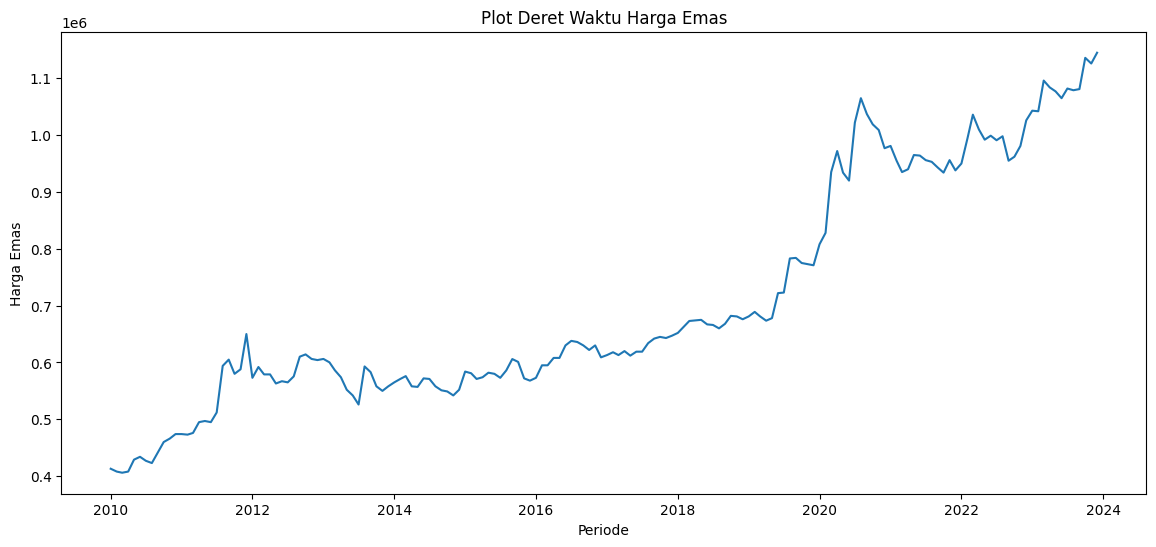

In [ ]:
# Plot deret harga emas (sebelum transformasi)

plt.figure(figsize=(14,6))
plt.plot(df.index, df['Price'])
plt.title('Plot Deret Waktu Harga Emas')
plt.xlabel('Periode')
plt.ylabel('Harga Emas')
plt.show()

**Q4. Jika dilihat berdasarkan plot deret apakah deret sudah stasioner dalam ragam?**

**Jawab:**

Berdasarkan plot deret waktu, deret harga emas belum stasioner dalam ragam. Hal ini terlihat dari besar fluktuasi data yang berubah sepanjang waktu. Pada periode awal, fluktuasi relatif lebih kecil, sedangkan pada periode sekitar 2020 hingga 2024 fluktuasi terlihat lebih besar. Kondisi tersebut menunjukkan bahwa ragam data belum konstan sepanjang waktu. Oleh karena itu, diperlukan transformasi, seperti transformasi Box-Cox, untuk membantu menstabilkan ragam data.

Untuk mengetahui kestasioneran deret dalam ragam dapat dicek melalui Uji Boxcox. Jika nilai $\lambda = 1$ atau angka 1 masuk dalam interval kepercayaan $\lambda$, maka dapat dikatakan bahwa deret sudah stasioner dalam ragam.

# Uji Boxcox

In [ ]:
from scipy.stats import boxcox, boxcox_llf

price_boxcox, lambda_boxcox = boxcox(df['Price'])
print('Lambda:', lambda_boxcox)

Lambda: -0.6757187582128565


nilai lambda: -0.6757187582128565
interval kepercayaan lambda: (-1.2297222872862736, -0.11104619896784432)


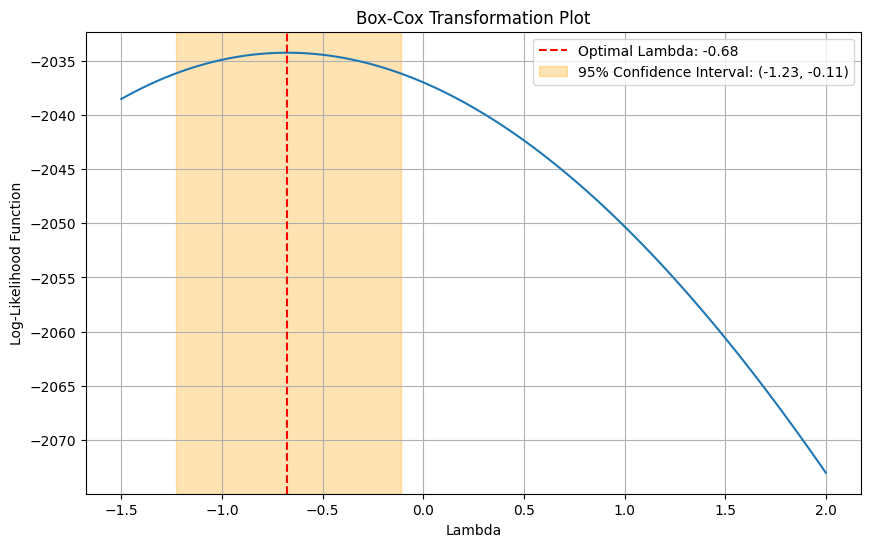

In [ ]:
data, lambda_fit, ci = boxcox(df['Price'], alpha=0.05)

print(f'nilai lambda: {lambda_fit}')
print(f'interval kepercayaan lambda: {ci}')

# Generate a range of lambda values
# lambdas = np.linspace(-0.5, 2, 100) -> (ini sintaks plot boxcox yang putus garis birunya)
lambdas = np.linspace(-1.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, df['Price']) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--',
            label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3,
            label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend()
plt.grid(True)
plt.show()

- Sumbu X: nilai lambda
- Sumbu Y: log-likelihood
- Puncak kurva: lambda yang menghasilkan log-likelihood terbesar
- Garis merah: lambda optimal hasil boxcox()
- Area/garis interval (kuning): 95% confidence interval lambda

**Q5. Bagaimana interpretasi Anda dari nilai lambda yang diperoleh?**

**Jawab:**

Berdasarkan plot transformasi Box–Cox, nilai lambda optimum diperoleh sebesar -0.68, yaitu pada titik dengan nilai log-likelihood maksimum. Interval kepercayaan 95% untuk lambda adalah (-1.23, -0.11). Karena nilai lambda = 1, yang merepresentasikan tidak diperlukannya transformasi, tidak termasuk dalam interval kepercayaan, maka data harga emas mengindikasikan perlunya transformasi untuk membantu menstabilkan ragam. Nilai lambda optimum yang negatif menunjukkan bahwa transformasi dengan pangkat negatif lebih sesuai untuk data harga emas.

# Transformasi Boxcox

Karena data tidak stasioner, perlu dilakukan transformasi Boxcox.

In [ ]:
data, lambda_fit, ci = boxcox(df['Price'], alpha=0.05)

print(f'nilai lambda: ', lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  -0.6757187582128565
interval kepercayaan lambda: (-1.2297222872862736, -0.11104619896784432)


In [ ]:
df['Price_BoxCox'] = data
df[['Price', 'Price_BoxCox']].head()

,Price,Price_BoxCox
Periode,,
2010-01-01,413000,1.479668
2010-02-01,408000,1.479666
2010-03-01,406000,1.479666
2010-04-01,408000,1.479666
2010-05-01,429000,1.479674


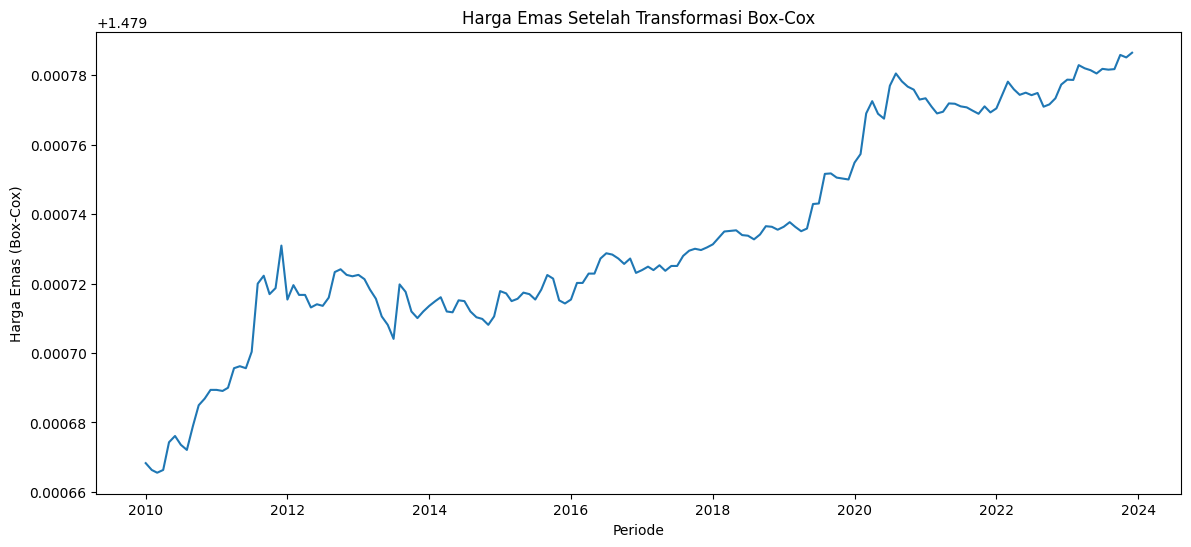

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Price_BoxCox'])
plt.title('Harga Emas Setelah Transformasi Box-Cox')
plt.xlabel('Periode')
plt.ylabel('Harga Emas (Box-Cox)')
plt.show()

In [ ]:
result = adfuller(df['Price_BoxCox'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')

for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -1.133482108691747
p-value: 0.7015366631549572
Critical Values:
   1%: -3.471374345647024
   5%: -2.8795521079291966
   10%: -2.5763733302850174


- ADF Statistic: -1.1335

- p-value: 0.7015

- Critical Value 5%: -2.8796

Karena p-value 0.7015 > 0.05, maka gagal menolak H0. Sehingga dapat disimpulkan bahwa data harga emas setelah transformasi Boxcox masih belum stasioner.

Hasil transformasi Box-Cox dengan λ = -0,68 belum stasioner dalam nilai tengah, sehingga perlu dilakukan **differencing** untuk mencapai stasioneritas dalam nilai tengah.

# Differencing

In [ ]:
df['Price_BoxCox_Diff1'] = df['Price_BoxCox'].diff()

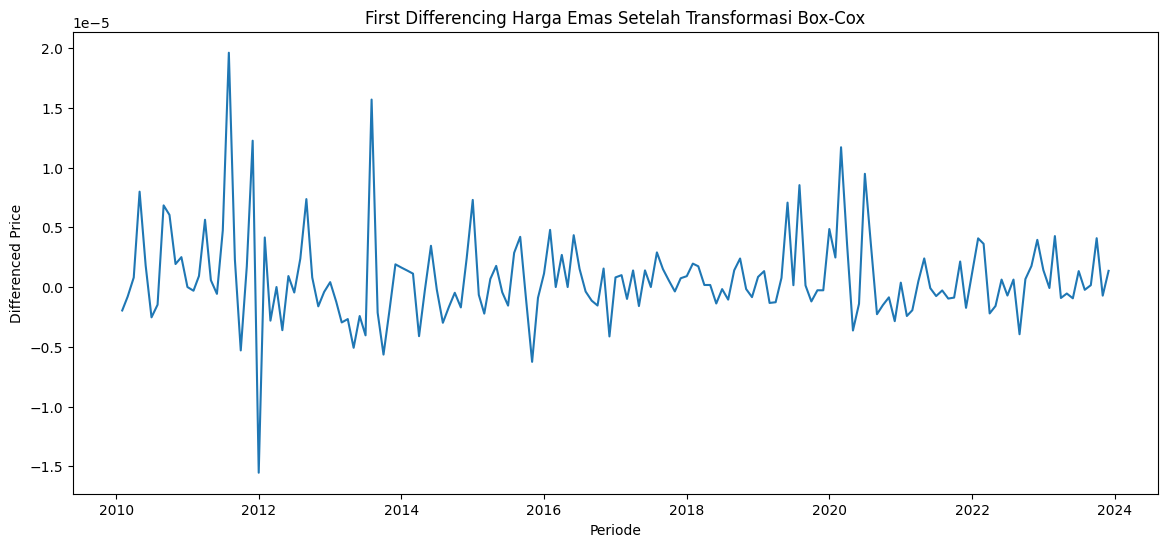

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Price_BoxCox_Diff1'])
plt.title('First Differencing Harga Emas Setelah Transformasi Box-Cox')
plt.xlabel('Periode')
plt.ylabel('Differenced Price')
plt.show()

In [ ]:
# Cek ADF
result_diff1 = adfuller(df['Price_BoxCox_Diff1'].dropna())

print('ADF Statistic:', result_diff1[0])
print('p-value:', result_diff1[1])
print('Critical Values:')

for key, value in result_diff1[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -5.933726027440773
p-value: 2.347581344455884e-07
Critical Values:
   1%: -3.471374345647024
   5%: -2.8795521079291966
   10%: -2.5763733302850174


- ADF Statistic: -5.9337

- p-value: $2.35 × 10^{-7}$

- Critical Value 5%: -2.8796

Karena p-value 0.000000235 < 0.05, maka H0 ditolak.

Selain itu,

nilai ADF Statistic -5.9337 < -2.8796, sehingga ADF Statistiv juga lebih kecil daripada critical value 5%.

Berdasarkan hasil Uji ADF, **deret harga emas setelah transformasi Box-Cox dan first differencing sudah stasioner dalam nilai tengah.**

# ACF dan PACF Setelah first differencing

<Figure size 1200x500 with 0 Axes>

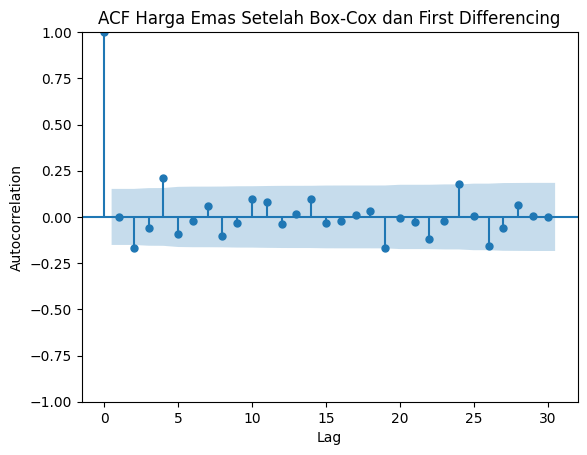

In [ ]:
# ACF
plt.figure(figsize=(12,5))
plot_acf(df['Price_BoxCox_Diff1'].dropna(), lags=30)
plt.title('ACF Harga Emas Setelah Box-Cox dan First Differencing')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

<Figure size 1200x500 with 0 Axes>

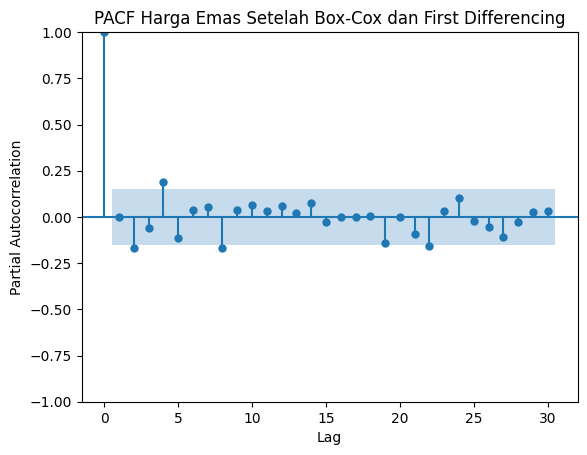

In [ ]:
# PACF
plt.figure(figsize=(12,5))
plot_pacf(df['Price_BoxCox_Diff1'].dropna(), lags=30, method='ywm')
plt.title('PACF Harga Emas Setelah Box-Cox dan First Differencing')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.show()

Setelah dilakukan transformasi Boxcox dan first differencing, plot ACF dan PACF menunjukkan bahwa sebagian besar nilai autokorelasi dan autokorelasi parsial berada di dalam batas kepercayaan dan berfluktuasi di sekitar nol. Pola ACF juga tidak lagi menunjukkan penurunan secara perlahan seperti pada data sebelum differencing. Hal ini menunjukkan bahwa ketergantungan jangka panjang pada deret telah berkurang dan mendukung hasil uji ADF bahwa deret telah stasioner. Meskipun terdapat beberapa lag yang melewati atau mendekati batas kepercayaan, tidak terlihat pola cut off maupun tail off yang jelas untuk langsung mengidentifikasi model AR atau MA tertentu.